In [1]:
import pandas as pd

## Loading wins and losses

In [2]:
player_data = pd.DataFrame(columns=['player_id', 'Player Name', 'Member'])

In [3]:
games_df = pd.DataFrame(columns=['team1_player1', 'team1_player2', 'team1_score', 'team2_player1', 'team2_player2'])

In [4]:
games_dicts = []

with open('../data/superbadder/20260421/games.txt', 'r') as f:
    for line in f:
        if '-' in line:
            team1, team2 = line.strip().split('-')
            team1_players_and_score = team1.strip().split(' and ')

            team1_score = team1_players_and_score[-1].split()[-1].strip()
            team1_player1 = team1_players_and_score[0]
            team1_player2 = ' '.join(team1_players_and_score[-1].split()[0:-1])

            team2_players_and_score = team2.strip().split(' and ')

            team2_score = team2_players_and_score[0].split()[0].strip()
            team2_player1 = team2_players_and_score[0].split(maxsplit=1)[1].strip()
            team2_player2 = team2_players_and_score[-1].strip()

            games_dicts.append(
                {
                    'team1_player1': team1_player1,
                    'team1_player2': team1_player2,
                    'team1_score': team1_score,
                    'team2_player1': team2_player1,
                    'team2_player2': team2_player2,
                    'team2_score': team2_score
                }
            )


In [5]:
games_df = pd.DataFrame(games_dicts)

In [6]:
# Returns all rows where 'your_string' is found in any column
games_df_filtered = games_df[games_df.apply(lambda row: row.astype(str).str.contains('Pritto').any(), axis=1)]

In [7]:
games_df_filtered

,team1_player1,team1_player2,team1_score,team2_player1,team2_player2,team2_score
2,Harry,Ravi,22,Suandi,Pritto,24
5,Andy,Ashutosh,13,Harry,Pritto,21
9,Thenes,Pritto,21,Trung,Ashutosh,12
13,Akhil Shrikanth,Ashutosh,18,Ulf,Pritto,21
17,Akhil Shrikanth,Pritto,21,Suandi,Mag,19
21,Suandi,Akhil Shrikanth,16,Sumit,Pritto,21
25,Andy,Pritto,21,Yaw,Ulf,18


In [30]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

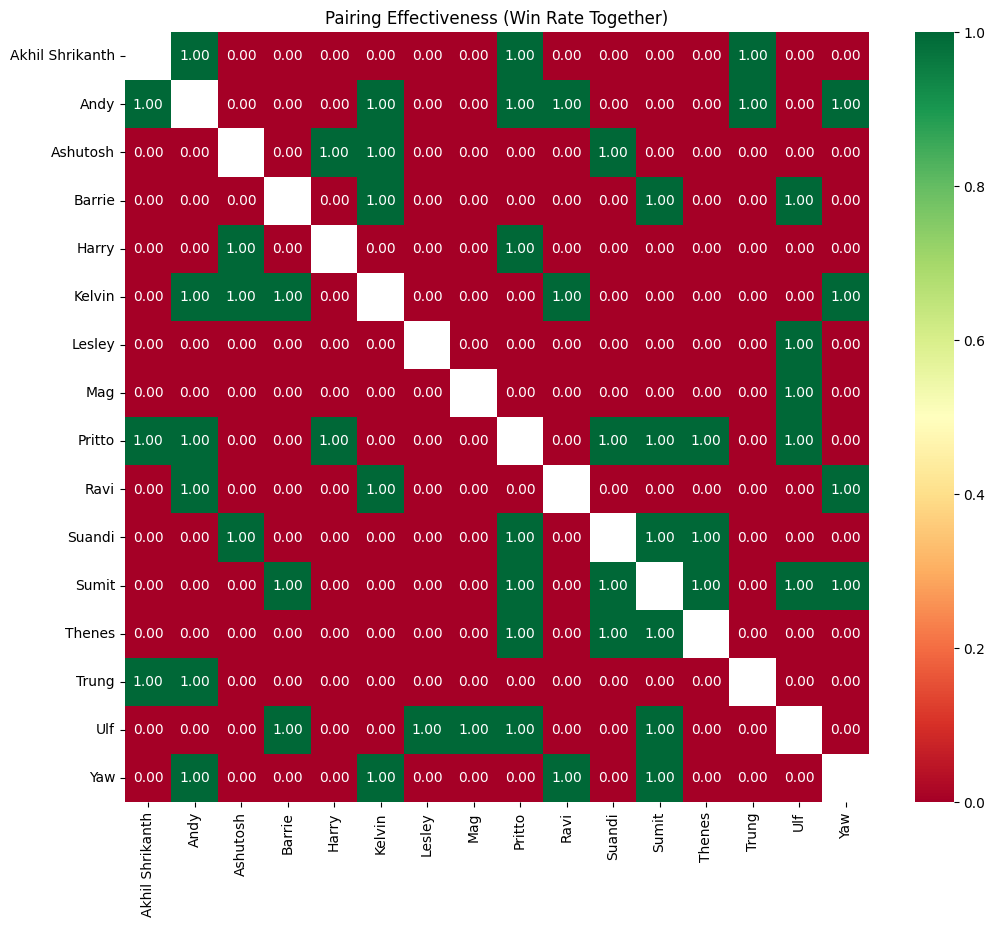

In [31]:
# 1. Prepare unique list of all players
players = sorted(list(set(games_df['team1_player1']) | set(games_df['team1_player2']) | 
                      set(games_df['team2_player1']) | set(games_df['team2_player2'])))

# 2. Initialize empty matrices for games played and wins
n = len(players)
counts = pd.DataFrame(np.zeros((n, n)), index=players, columns=players)
wins = pd.DataFrame(np.zeros((n, n)), index=players, columns=players)

# 3. Populate the matrices
for _, row in games_df.iterrows():
    # Process Team 1
    p1, p2 = sorted([row['team1_player1'], row['team1_player2']])
    counts.loc[p1, p2] += 1
    counts.loc[p2, p1] += 1
    if row['team1_score'] > row['team2_score']:
        wins.loc[p1, p2] += 1
        wins.loc[p2, p1] += 1
        
    # Process Team 2
    p3, p4 = sorted([row['team2_player1'], row['team2_player2']])
    counts.loc[p3, p4] += 1
    counts.loc[p4, p3] += 1
    if row['team2_score'] > row['team1_score']:
        wins.loc[p3, p4] += 1
        wins.loc[p4, p3] += 1

# Calculate Win Rate (Win Matrix / Count Matrix)
win_rate = (wins / counts).fillna(0)

# 4. Visualization: Partnership Win Rate
plt.figure(figsize=(12, 10))
sns.heatmap(win_rate, 
            annot=True,       # Show win rate numbers
            cmap='RdYlGn',    # Green for high win rate, Red for low
            fmt='.2f',        # Format to 2 decimal places
            mask=np.eye(n))   # Hide the diagonal (player playing with themselves)

plt.title('Pairing Effectiveness (Win Rate Together)')
plt.show()

In [32]:
# Function to build a pairing matrix based on a metric
def build_pairing_matrix(df, metric='count'):
    unique_players = sorted(list(set(df['team1_player1']) | set(df['team1_player2']) | 
                                 set(df['team2_player1']) | set(df['team2_player2'])))
    
    # Initialize matrices
    count_matrix = pd.DataFrame(0.0, index=unique_players, columns=unique_players)
    win_matrix = pd.DataFrame(0.0, index=unique_players, columns=unique_players)
    
    for _, row in df.iterrows():
        # Team 1 pairing
        p1, p2 = sorted([row['team1_player1'], row['team1_player2']])
        count_matrix.loc[p1, p2] += 1
        count_matrix.loc[p2, p1] += 1
        if row['team1_score'] > row['team2_score']:
            win_matrix.loc[p1, p2] += 1
            win_matrix.loc[p2, p1] += 1
            
        # Team 2 pairing
        p3, p4 = sorted([row['team2_player1'], row['team2_player2']])
        count_matrix.loc[p3, p4] += 1
        count_matrix.loc[p4, p3] += 1
        if row['team2_score'] > row['team1_score']:
            win_matrix.loc[p3, p4] += 1
            win_matrix.loc[p4, p3] += 1
            
    if metric == 'win_rate':
        # Calculate win rate, handling division by zero
        return (win_matrix / count_matrix).fillna(0)
    return count_matrix

In [33]:
# Generate the matrices
count_mtx = build_pairing_matrix(games_df, 'count')
win_rate_mtx = build_pairing_matrix(games_df, 'win_rate')

In [34]:
# Plot 1: Partnership Frequency
plt.figure(figsize=(10, 8))
sns.heatmap(count_mtx, annot=True, cmap='Blues', fmt='.0f')
plt.title('Partnership Frequency (Games Played Together)')
plt.savefig('partnership_frequency.png')
plt.close()